In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, auc
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("../dataset/Mohammadinia_kg/heart_preprocess.csv")

In [3]:
df.isnull().sum()

Unnamed: 0                  0
Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1319 non-null   int64  
 1   Age                       1319 non-null   int64  
 2   Gender                    1319 non-null   int64  
 3   Heart rate                1319 non-null   int64  
 4   Systolic blood pressure   1319 non-null   int64  
 5   Diastolic blood pressure  1319 non-null   int64  
 6   Blood sugar               1319 non-null   float64
 7   CK-MB                     1319 non-null   float64
 8   Troponin                  1319 non-null   float64
 9   Result                    1319 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 103.2 KB


In [5]:
df.describe()

,Unnamed: 0,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,659.000000,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942,0.385898
std,380.906813,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568,0.486991
min,0.000000,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000,0.000000
25%,329.500000,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000,0.000000
50%,659.000000,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000,0.000000
75%,988.500000,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500,1.000000
max,1318.000000,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Result'].value_counts()

Result
0    810
1    509
Name: count, dtype: int64

In [8]:
df['Result'] = np.where(df['Result'] == 0, 0, 1)

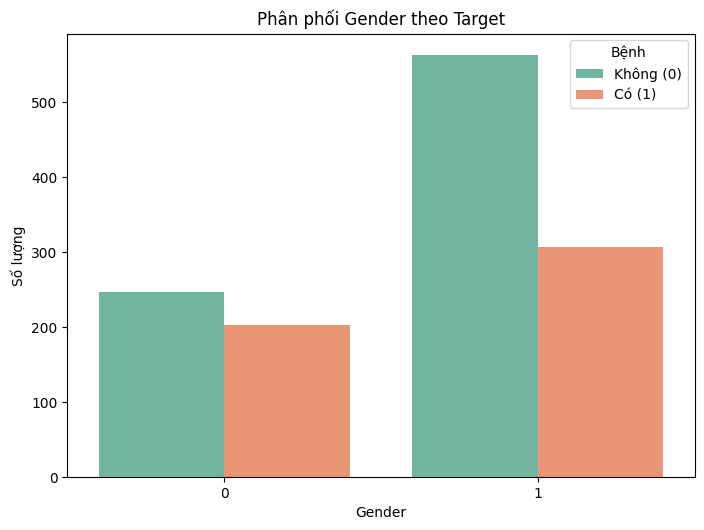

In [9]:
categorical_features = ["Gender"]

plt.figure(figsize=(20, 15))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='Result', data=df, palette='Set2')
    plt.title(f'Phân phối {col} theo Target')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.legend(title='Bệnh', labels=['Không (0)', 'Có (1)'])

plt.tight_layout()
plt.show()

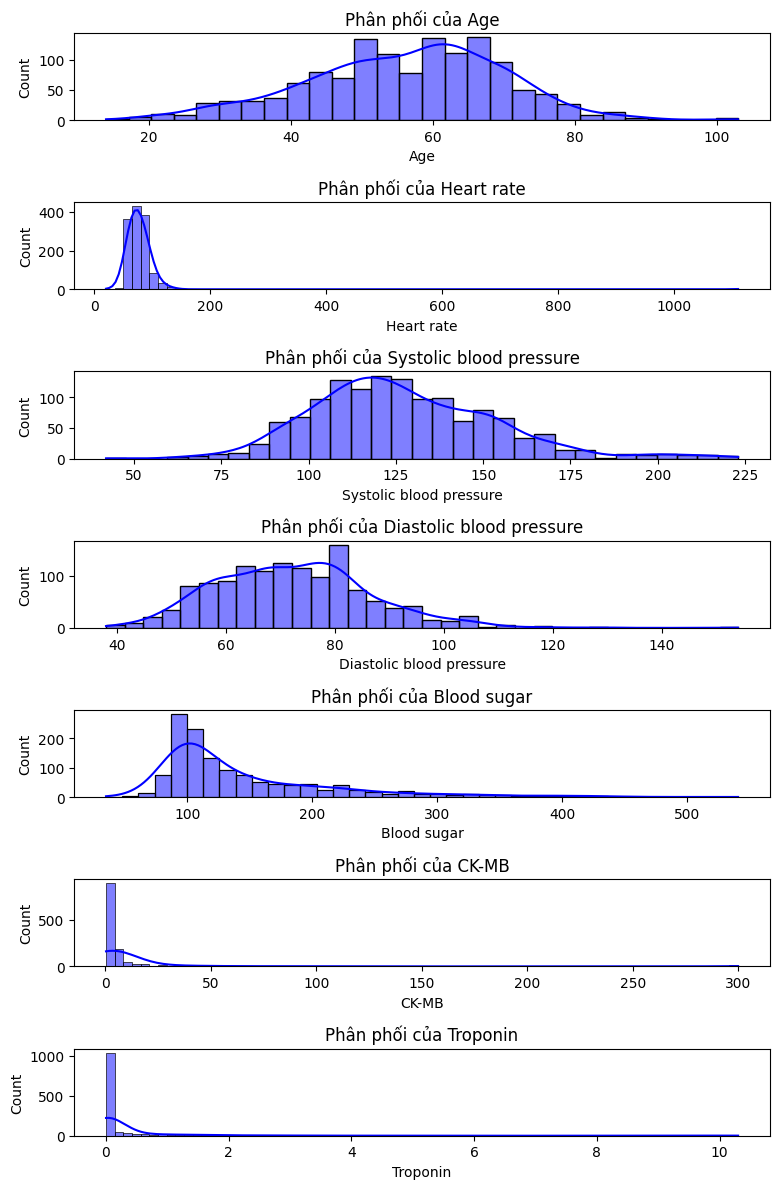

In [10]:
continuous_features = [    "Age",                         # tuổi
    "Heart rate",    # enzyme CPK
    "Systolic blood pressure",           # EF (%)
    "Diastolic blood pressure",                   # tiểu cầu
    "Blood sugar",            # creatinine máu
    "CK-MB",    
    "Troponin"]

plt.figure(figsize=(15, 12))
for i, col in enumerate(continuous_features):
    plt.subplot(len(continuous_features), 2, 2*i + 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Phân phối của {col}')
    

plt.tight_layout()
plt.show()

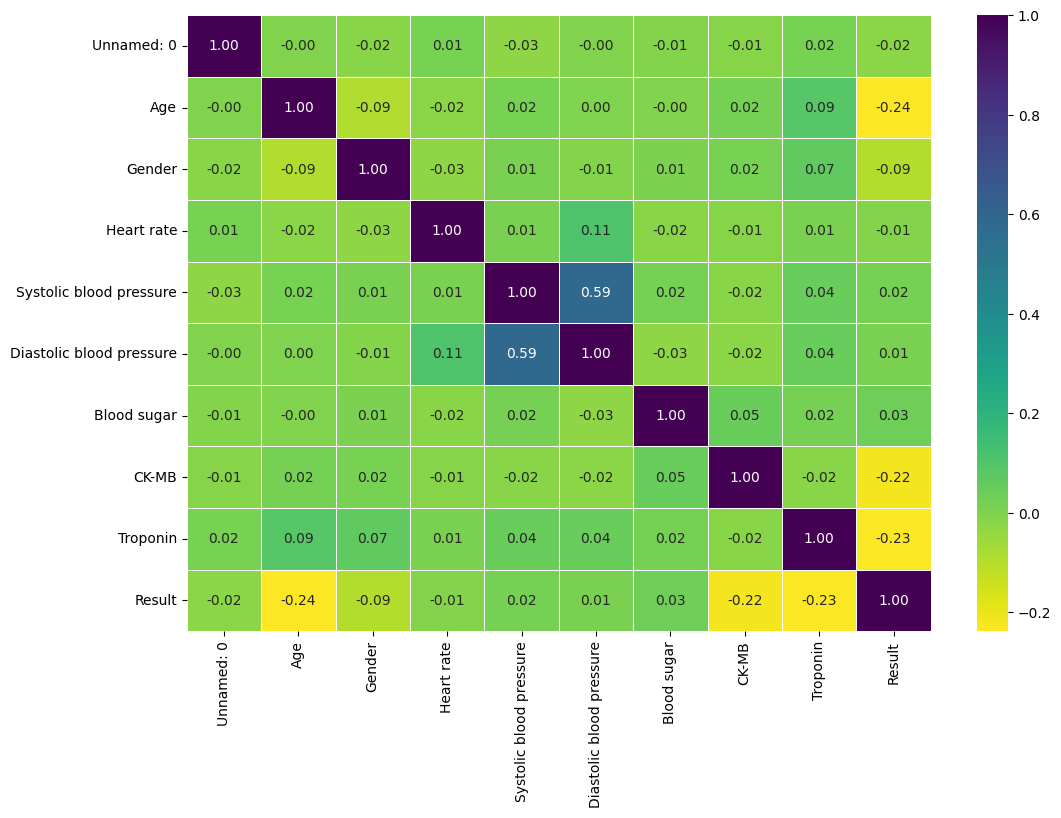

In [11]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, linewidth=0.5, fmt='.2f', cmap='viridis_r');